### **CI/CD DEMO - CREATE CANDIDATE**
#### **TEAM 04 STUDENT 3 - TING ENG KIAT (S403)**
#### **Jupyter Notebook Version: 26 August 2026**

**CI/CD WORKFLOW WITH RETRAINING TRIGGER ARCHIRECTURE**

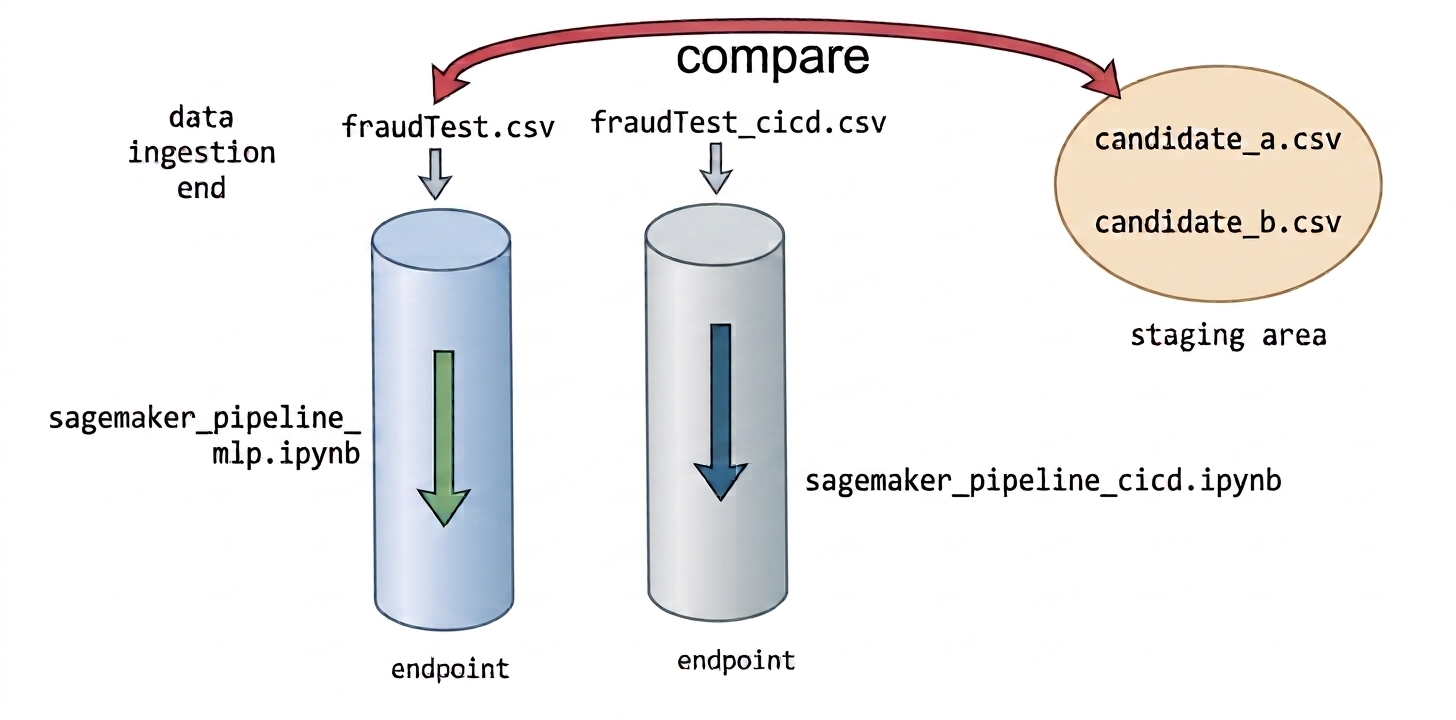

#### **STEP 01: CREATE TWO VALIDATED CANDIDATES**

In [1]:
def psi(expected, actual, bins=10):
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf
    e_pct = np.clip(np.histogram(expected, breakpoints)[0] / len(expected), 1e-4, None)
    a_pct = np.clip(np.histogram(actual, breakpoints)[0] / len(actual), 1e-4, None)
    return np.sum((a_pct - e_pct) * np.log(a_pct / e_pct))

import pandas as pd
import numpy as np

df = pd.read_csv("s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/raw/fraudTest.csv")
print(f"Loaded {len(df)} rows")

# ---- Candidate A: BELOW threshold (no drift) ----
candidate_a = df.sample(n=100000, random_state=42).copy()
psi_a = psi(df['amt'], candidate_a['amt'])
print(f"Candidate A PSI: {psi_a:.3f}  ({'OK, below threshold' if psi_a < 0.2 else 'too high, adjust'})")

# ---- Candidate B: ABOVE threshold (strong drift) ----
candidate_b = df.sample(n=100000, random_state=123).copy()
drift_idx = candidate_b.sample(frac=0.50, random_state=11).index
candidate_b.loc[drift_idx, 'amt'] = candidate_b.loc[drift_idx, 'amt'] * 8
psi_b = psi(df['amt'], candidate_b['amt'])
print(f"Candidate B PSI: {psi_b:.3f}  ({'OK, above threshold' if psi_b > 0.2 else 'too low, adjust'})")

# ---- Save only if both are correct ----
if psi_a < 0.2 and psi_b > 0.2:
    candidate_a.to_csv("candidate_a.csv", index=False)
    candidate_b.to_csv("candidate_b.csv", index=False)
    print("Both candidates saved.")
else:
    print("Adjust parameters and re-run before saving.")

Loaded 555719 rows
Candidate A PSI: 0.000  (OK, below threshold)


Candidate B PSI: 0.542  (OK, above threshold)


Both candidates saved.


#### **STEP 02: S3 SETUP FOR UPLOADS**

In [1]:
import boto3

BUCKET = "nyp-26s1-iti113"
TEAM_ID = "team04"
PROJECT_NAME = "credit-card-fraud-detection"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"
STAGING_KEY = f"{PREFIX}/staging/candidate.csv"

s3 = boto3.client('s3')

#### **STEP 03: RESET FRAUDTEST_CICD**

In [2]:
### RESET FRAUDTEST_CICD (RUN MANUALLY BEFORE A FRESH CI/CD DEMO)
s3.copy_object(
    Bucket=BUCKET,
    CopySource=f"{BUCKET}/{PREFIX}/raw/fraudTest.csv",
    Key=f"{PREFIX}/raw/fraudTest_cicd.csv"
)
print("fraudTest_cicd.csv reset to original 555k baseline.")

fraudTest_cicd.csv reset to original 555k baseline.


#### **STEP 04: UPLOAD CANDIDATE A (BELOW THRESHOLD)**

In [3]:
s3.upload_file("candidate_a.csv", BUCKET, STAGING_KEY)
print("Candidate A uploaded to staging.")

Candidate A uploaded to staging.


**=> CHECK CI/CD POLLING SCRIPT OUTPUT**

#### **STEP 05: UPLOAD CANDIDATE B (ABOVE THRESHOLD)**

In [4]:
s3.upload_file("candidate_b.csv", BUCKET, STAGING_KEY)
print("Candidate B uploaded to staging.")

Candidate B uploaded to staging.


**=> CHECK CI/CD POLLING SCRIPT OUTPUT**

#### **STEP 06: GET LATEST PIPELINE EXECUTION**

In [5]:
import boto3
sm = boto3.client('sagemaker')
PIPELINE_NAME = "iti113-team04-credit-card-fraud-detection"

executions = sm.list_pipeline_executions(PipelineName=PIPELINE_NAME, SortOrder='Descending', MaxResults=1)
latest = executions['PipelineExecutionSummaries'][0]
print(latest['PipelineExecutionArn'])
print(latest['PipelineExecutionStatus'])
print(latest['StartTime'])

arn:aws:sagemaker:ap-southeast-1:044528205969:pipeline/iti113-team04-credit-card-fraud-detection/execution/h7cseho452sl
Executing
2026-08-26 11:33:24.443000+00:00


#### **STEP 07: PIPELINE MONITORING**

In [6]:
import time

while True:
    status = sm.describe_pipeline_execution(PipelineExecutionArn=latest['PipelineExecutionArn'])['PipelineExecutionStatus']

    steps = sm.list_pipeline_execution_steps(PipelineExecutionArn=latest['PipelineExecutionArn'])['PipelineExecutionSteps']
    running_steps = [s['StepName'] for s in steps if s['StepStatus'] == 'Executing']
    current = running_steps[0] if running_steps else status

    print(f"{status} — stage: {current}")

    if status in ('Succeeded', 'Failed', 'Stopped'):
        print(f"\nFinal status: {status}")
        break

    time.sleep(10)

Executing — stage: Team04-PreprocessData


Executing — stage: Team04-PreprocessData


Executing — stage: Team04-PreprocessData


Executing — stage: Team04-PreprocessData


Executing — stage: Team04-PreprocessData


...

Executing — stage: Team04-TrainModel


Executing — stage: Team04-TrainModel


Executing — stage: Team04-TrainModel


Executing — stage: Team04-TrainModel


Succeeded — stage: Succeeded

Final status: Succeeded


**RESULTS:**

**Retraining Triggered:**

```
Executing — stage: Team04-PreprocessData
Executing — stage: Team04-PreprocessData
Executing — stage: Team04-PreprocessData
Executing — stage: Team04-PreprocessData
Executing — stage: Team04-PreprocessData
Executing — stage: Team04-PreprocessData
Executing — stage: Team04-PreprocessData
Executing — stage: Team04-PreprocessData
Executing — stage: Team04-PreprocessData
Executing — stage: Team04-PreprocessData
Executing — stage: Executing
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Team04-TrainModel
Executing — stage: Executing
Succeeded — stage: Succeeded

Final status: Succeeded
```